In [86]:
import yaml

with open("config.base_s_25_elec_.yaml") as stream:
    try:
        config_original = (yaml.safe_load(stream))
    except yaml.YAMLError as exc:
        print(exc)

In [115]:
solver_options_net = config_original["solving"]["solver_options"]["gurobi-default"]
solver_name = config_original["solving"][("solver")]
solver_name = {'solver_name': "gurobi"}
solver_options = solver_name | solver_options_net
solver_options

{'solver_name': 'gurobi',
 'threads': 32,
 'method': 2,
 'crossover': 0,
 'BarConvTol': 1e-05,
 'Seed': 123,
 'AggFill': 0,
 'PreDual': 0,
 'GURO_PAR_BARDENSETHRESH': 200}

In [1]:
import pypsa
import fbmc  # noqa: F401  not unused; registers pypsa.Network.fbmc accessor
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import networkx as nx


{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x3ab98c550>},
 'branches': {'Line': <matplotlib.collections.LineCollection at 0x14b752f10>,
  'Link': <matplotlib.collections.LineCollection at 0x14b903910>},
 'flows': {}}

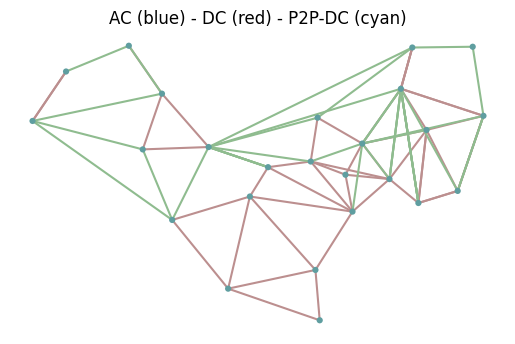

In [130]:
import cartopy
line_color = nodal_net.lines.bus0.map(nodal_net.buses.carrier).map(
    lambda ct: "r" if ct == "DC" else "b"
)

nodal_net.plot.map(
    title="AC (blue) - DC (red) - P2P-DC (cyan)",
    jitter=0.4,
)

In [116]:
nodal_net = pypsa.Network("base_s_25_elec_.nc")
nodal_net.buses.rename(columns={"country": "zone_name"}, inplace=True)
bus_zone_map = nodal_net.buses['zone_name']
zonal_net = nodal_net.fbmc.to_zonal(bus_zone_map)

INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units


Skipping missing attribute loss


In [123]:
config = fbmc.FBMCConfig(
    base_case_strategy=fbmc.BaseCaseStrategy.NODAL_OPTIMUM,
    add_security_constraints=False,
    gsk_strategy=fbmc.GSKStrategy.CURRENT_GENERATION,
    security_constraint_bodf_size_threshold=0.1,
    min_ram=0.1,
    reliability_margin_factor=0.0,
    advanced_hybrid_coupling_flag= True,
    #solver_kwargs={'solver_name': 'gurobi', 'OutputFlag': 0},
    solver_kwargs=solver_options
)

zonal_net.fbmc.create_model(nodal_net, config=config)
zonal_net.model.solve(**config.solver_kwargs)
result = zonal_net.fbmc.results()
print(result)

       'relation/15772117-320-DC', 'relation/15781671-525-DC',
       'relation/2127794-270-DC', 'relation/2505320-400-DC',
       'relation/8184641-200-DC', 'relation/8185420-320-DC',
       'relation/8185487-400-DC', 'relation/8193755-320-DC', 'TYNDP2020_17',
       'TYNDP2020_32', 'TYNDP2020_36', 'DC2', 'TYNDP2024_153', 'TYNDP2024_285',
       'TYNDP2022_286'],
      dtype='object', name='Link')


ValueError: Copying a solved network with an attached solver model is not supported. Please delete the model first using `n.model.solver_model = None`.

In [10]:
result.zonal_net.model.constraints

linopy.model.Constraints
------------------------
 * Generator-ext-p_nom-lower (Generator-ext)
 * Generator-ext-p_nom-upper (Generator-ext)
 * Link-ext-p_nom-lower (Link-ext)
 * Link-ext-p_nom-upper (Link-ext)
 * StorageUnit-ext-p_nom-lower (StorageUnit-ext)
 * StorageUnit-ext-p_nom-upper (StorageUnit-ext)
 * Generator-fix-p-lower (snapshot, Generator-fix)
 * Generator-fix-p-upper (snapshot, Generator-fix)
 * Generator-ext-p-lower (snapshot, Generator-ext)
 * Generator-ext-p-upper (snapshot, Generator-ext)
 * Link-ext-p-lower (snapshot, Link-ext)
 * Link-ext-p-upper (snapshot, Link-ext)
 * StorageUnit-ext-p_dispatch-lower (snapshot, StorageUnit-ext)
 * StorageUnit-ext-p_dispatch-upper (snapshot, StorageUnit-ext)
 * StorageUnit-ext-p_store-lower (snapshot, StorageUnit-ext)
 * StorageUnit-ext-p_store-upper (snapshot, StorageUnit-ext)
 * StorageUnit-ext-state_of_charge-lower (snapshot, StorageUnit-ext)
 * StorageUnit-ext-state_of_charge-upper (snapshot, StorageUnit-ext)
 * StorageUnit-ene

In [20]:
result.zonal_net.model.constraints['CNEC-upper-RAM-subnet-0'].sel(snapshot=zonal_net.snapshots[10]).sel(cnec="2")

Constraint `CNEC-upper-RAM-subnet-0`
------------------------------------
-0.187 Zone-p[2013-03-01 10:00:00, DE] ≤ 12474.449599744848

In [12]:
con = result.zonal_net.model.constraints['Zone-definition'].sel(snapshot=zonal_net.snapshots[0]).sel(Zone="BE")
print(str(con))

Constraint `Zone-definition`
----------------------------
+1 Zone-p[2013-03-01 00:00:00, BE] - 1 Generator-p[2013-03-01 00:00:00, BE0 0 CCGT] - 1 Generator-p[2013-03-01 00:00:00, BE0 0 OCGT] ... -1 StorageUnit-p_dispatch[2013-03-01 00:00:00, BE0 0 battery] + 1 StorageUnit-p_store[2013-03-01 00:00:00, BE0 0 battery] + 1 Link-p[2013-03-01 00:00:00, relation/8193755-320-DC] = -10150.999992370605


In [10]:
result.zonal_net.model.constraints['CNEC-lower-RAM-subnet-0'].sel(snapshot=zonal_net.snapshots[0])

Constraint `CNEC-lower-RAM-subnet-0` [cnec: 15]:
------------------------------------------------
[0]: -0.5116 Zone-p[2013-03-01 00:00:00, DE] - 0.5992 Zone-p[2013-03-01 00:00:00, NL]  ≥ -2798.284081149478
[1]: -0.4884 Zone-p[2013-03-01 00:00:00, DE] - 0.4008 Zone-p[2013-03-01 00:00:00, NL]  ≥ -3314.885321116425
[10]: +0.03118 Zone-p[2013-03-01 00:00:00, DE]                                         ≥ -4727.512806574352
[11]: +0.07794 Zone-p[2013-03-01 00:00:00, DE]                                         ≥ -26193.84472864287
[12]: -0.03624 Zone-p[2013-03-01 00:00:00, DE]                                         ≥ -6568.791078020348
[13]: +0.03494 Zone-p[2013-03-01 00:00:00, DE]                                         ≥ -6542.823244299205
[14]: -0.5116 Zone-p[2013-03-01 00:00:00, DE] + 0.1362 Zone-p[2013-03-01 00:00:00, NL] ≥ -9552.020435697692
		...
[3]: -0.2697 Zone-p[2013-03-01 00:00:00, DE]                                           ≥ -11238.855601234194
[4]: -0.1454 Zone-p[2013-03-01 

In [139]:
d = nodal_net.buses.apply(lambda row: (row["x"], row["y"]), axis=1).to_dict()
d

{'BE0 0': (5.139284238571429, 50.68561860171428),
 'DE0 0': (7.239637820731708, 51.37830108810975),
 'DE0 1': (11.40887984148936, 48.80724648893617),
 'DE0 2': (13.094428980806452, 52.452413288870964),
 'DE0 3': (9.25141665419355, 53.4362586617742),
 'DE0 4': (8.705499178787878, 49.17755361858586),
 'DE0 5': (10.195867937435898, 51.594052309487175),
 'NL0 0': (4.481626574117647, 52.059696368235294),
 'NL0 1': (6.183861166470588, 52.56340226882353)}

In [140]:
nodal_net.buses[["x","y"]].to_dict(orient = 'index')

{'BE0 0': {'x': 5.139284238571429, 'y': 50.68561860171428},
 'DE0 0': {'x': 7.239637820731708, 'y': 51.37830108810975},
 'DE0 1': {'x': 11.40887984148936, 'y': 48.80724648893617},
 'DE0 2': {'x': 13.094428980806452, 'y': 52.452413288870964},
 'DE0 3': {'x': 9.25141665419355, 'y': 53.4362586617742},
 'DE0 4': {'x': 8.705499178787878, 'y': 49.17755361858586},
 'DE0 5': {'x': 10.195867937435898, 'y': 51.594052309487175},
 'NL0 0': {'x': 4.481626574117647, 'y': 52.059696368235294},
 'NL0 1': {'x': 6.183861166470588, 'y': 52.56340226882353}}

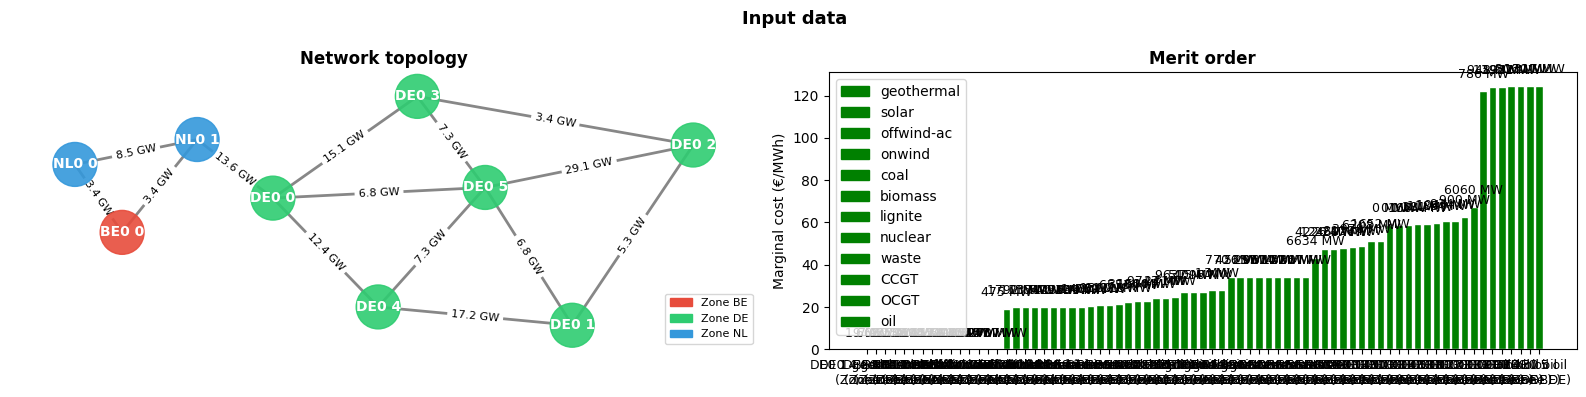

In [8]:
zone_colors   = {'BE': '#E74C3C', 'DE': '#2ECC71', 'NL': '#3498DB'}
carrier_colors = {'CCGT': "green", 'OCGT':"green", 'biomass':"green", 'nuclear':"green", 'oil':"green", 'waste':"green", 'coal':"green", 'lignite':"green", 'geothermal':"green", 'onwind':"green", 'offwind-ac':"green", 'solar':"green"}

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Network topology
ax = axes[0]
#pos = {'A1': (-2, 0), 'B1': (0, 1.2), 'B2': (0, -1.2), 'C1': (2, 0)}
pos = nodal_net.buses.apply(lambda row: (row["x"], row["y"]), axis=1).to_dict()
G = nx.Graph()
G.add_nodes_from(nodal_net.buses.index)
for l in nodal_net.lines.itertuples():
    G.add_edge(l.bus0, l.bus1, s_nom=l.s_nom)

nx.draw_networkx_nodes(G, pos, ax=ax,
    node_color=[zone_colors[nodal_net.buses.loc[b, 'zone_name']] for b in G.nodes()],
    node_size=1000, alpha=0.9)
nx.draw_networkx_labels(G, pos, ax=ax, font_weight='bold', font_color='white', font_size=10)
nx.draw_networkx_edges(G, pos, ax=ax,
    width=2, edge_color='#555', alpha=0.7)
nx.draw_networkx_edge_labels(G, pos,
    {(u, v): f"{round(G[u][v]['s_nom']/1000,1)} GW" for u, v in G.edges()}, font_size=8, ax=ax)
ax.legend(handles=[mpatches.Patch(color=c, label=f'Zone {z}') for z, c in zone_colors.items()],
          loc='lower right', fontsize=8)
ax.set_title('Network topology', fontweight='bold')
ax.axis('off')

# Merit order
ax = axes[1]
gens = nodal_net.generators.copy()
gens['zone'] = nodal_net.buses.loc[gens['bus'], 'zone_name'].values
gens = gens.sort_values('marginal_cost')
ax.bar(range(len(gens)), gens['marginal_cost'],
       color=[carrier_colors[c] for c in gens['carrier']], edgecolor='white')
for i, (_, row) in enumerate(gens.iterrows()):
    ax.text(i, row['marginal_cost'] + 6, f"{int(row['p_nom'])} MW", ha='center', fontsize=9)
ax.set_xticks(range(len(gens)))
ax.set_xticklabels([f"{idx}\n(Zone {row['zone']})" for idx, row in gens.iterrows()], fontsize=9)
ax.set_ylabel('Marginal cost (€/MWh)')
ax.set_title('Merit order', fontweight='bold')
ax.legend(handles=[mpatches.Patch(color=carrier_colors[c], label=c) for c in gens['carrier'].unique()])


plt.suptitle('Input data', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
from fbmc.post_processing.main import process_results

In [132]:
process_results(result, rd_cost= None, rd_dispatch= None, save_path = "/Users/ng-work/Models/pypsa-fbmc/nathan_tests/3-zones/results", config = config)

NameError: name 'process_results' is not defined

In [10]:
from src.redispatch.main import run_redispatch
redispatch_results = run_redispatch(nodal_net, result.dispatch_results, security_constrained_flag=False)

ValueError: conflicting sizes for dimension 'Generator': length 73 on the data but length 82 on coordinate 'Generator'

In [137]:
nodal_net

PyPSA Network 'Unnamed Network'
-------------------------------
Components:
 - Bus: 9
 - Carrier: 16
 - Generator: 82
 - Line: 15
 - Link: 14
 - Load: 9
 - StorageUnit: 9
 - SubNetwork: 1
Snapshots: 24

In [138]:
process_results(result, rd_cost= None, rd_dispatch= None, save_path = "/Users/ng-work/Models/pypsa-fbmc/nathan_tests/3-zones/results", config = config)

NameError: name 'process_results' is not defined